In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    accuracy_score
)

In [4]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset Shape:", X.shape)
print("\nTarget Classes:")
print(y.value_counts())

X.head()

Dataset Shape: (569, 30)

Target Classes:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
print("Missing Values:")
print(X.isnull().sum().sum())

print("\nData Types:")
print(X.dtypes.value_counts())

print("\nTarget Names:")
print(data.target_names)

Missing Values:
0

Data Types:
float64    30
Name: count, dtype: int64

Target Names:
['malignant' 'benign']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed.")

Standardization completed.


In [9]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [10]:
y_pred = logistic_model.predict(X_test_scaled)

y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predicted Classes:")
print(y_pred[:10])

print("\nPredicted Probabilities:")
print(y_prob[:10])

Predicted Classes:
[0 1 0 1 0 1 1 0 0 0]

Predicted Probabilities:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]


In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112


Confusion Matrix:
[[41  1]
 [ 1 71]]


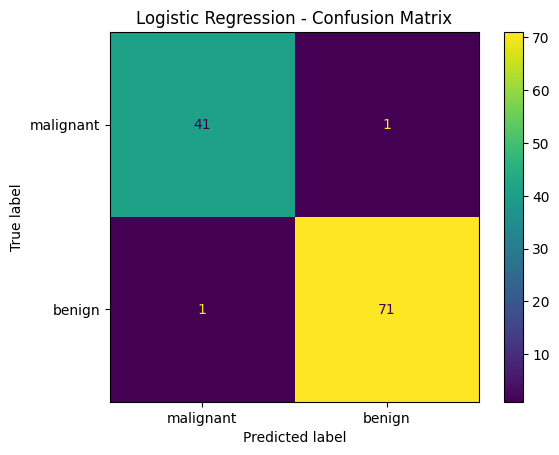

In [12]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [13]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [14]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)


ROC-AUC Score: 0.9953703703703703


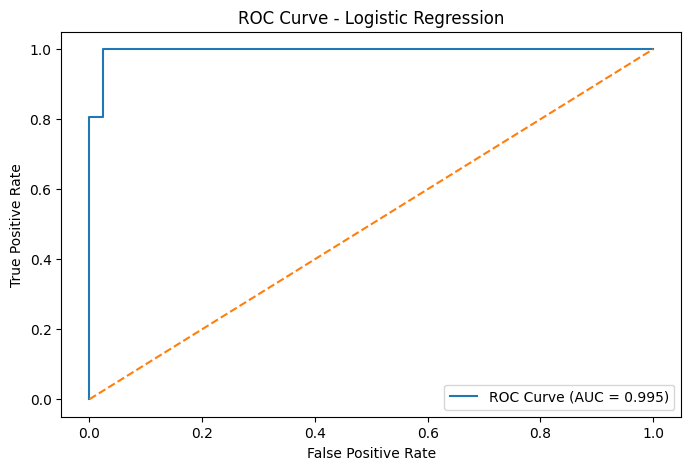

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


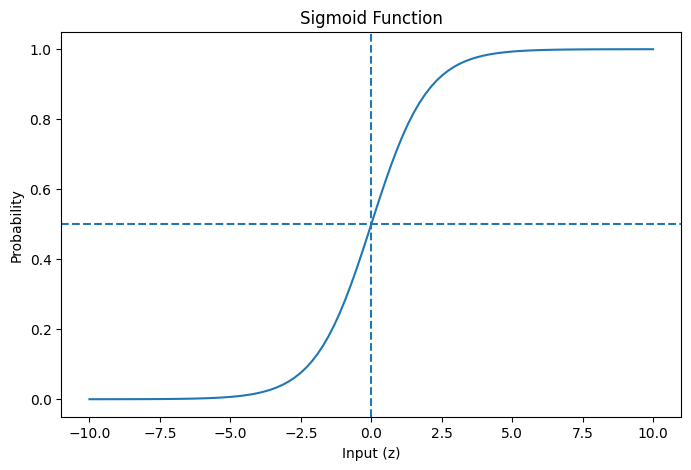

In [16]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)

probabilities = sigmoid(z)

plt.figure(figsize=(8, 5))

plt.plot(z, probabilities)

plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Input (z)")
plt.ylabel("Probability")
plt.title("Sigmoid Function")

plt.show()

In [17]:
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for threshold in thresholds_to_test:

    custom_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, custom_pred, zero_division=0)
    recall = recall_score(y_test, custom_pred, zero_division=0)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall
0,0.3,0.972973,1.000000
1,0.4,0.986111,0.986111
2,0.5,0.986111,0.986111
3,0.6,0.985507,0.944444
4,0.7,0.985294,0.930556


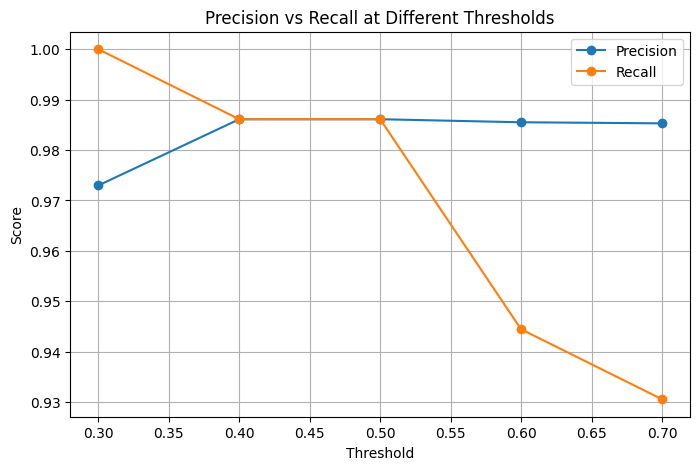

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Thresholds")
plt.legend()
plt.grid()

plt.show()

In [19]:
print("===== FINAL MODEL RESULTS =====")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("ROC-AUC  :", roc_auc)

===== FINAL MODEL RESULTS =====
Accuracy : 0.9824561403508771
Precision: 0.9852941176470589
Recall   : 0.9305555555555556
ROC-AUC  : 0.9953703703703703


In [20]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients)

                    Feature  Coefficient
5          mean compactness     0.648342
15        compactness error     0.647227
19  fractal dimension error     0.437894
18           symmetry error     0.360492
11            texture error     0.248823
9    mean fractal dimension     0.199732
16          concavity error     0.160563
25        worst compactness     0.055514
14         smoothness error    -0.160276
8             mean symmetry    -0.167233
29  worst fractal dimension    -0.187251
4           mean smoothness    -0.212479
17     concave points error    -0.443784
2            mean perimeter    -0.476298
0               mean radius    -0.511479
3                 mean area    -0.541059
12          perimeter error    -0.544333
1              mean texture    -0.552698
6            mean concavity    -0.602103
7       mean concave points    -0.704156
24         worst smoothness    -0.746625
22          worst perimeter    -0.763220
26          worst concavity    -0.823151
13              

## Conclusion

Logistic Regression was successfully implemented for binary classification using the Breast Cancer Wisconsin Dataset.

The dataset was divided into training and testing sets and the features were standardized using StandardScaler.

The Logistic Regression model was evaluated using Accuracy, Precision, Recall, Confusion Matrix, and ROC-AUC score.

The ROC curve was used to understand the classification performance, while different probability thresholds were tested to observe the trade-off between Precision and Recall.

The sigmoid function was also visualized to understand how Logistic Regression converts model outputs into probabilities.

Overall, Logistic Regression provided effective performance for this binary classification problem.